# Household Waste Classification Using a Neural Network Implemented from Scratch

## Technical Report Companion Notebook

This notebook accompanies the technical report for the Foundations of Machine Learning final project (Track 2). It implements a multi-layer perceptron (MLP) from scratch using only NumPy, trains it on the Garbage Dataset (Kunwar, 2026), and demonstrates incremental improvements through architectural and hyperparameter tuning.

# Setup and Dataset download (utilising the kagglehub functions)

In [11]:
# Setup dependencies
import os
import warnings
warnings.filterwarnings('ignore')
import subprocess
import sys
import datetime
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# numpy setup for reprocebility 
np.random.seed(42)
print("NumPy version:", np.__version__)

NumPy version: 2.5.1


# Helperfunctions fir dataset download and userinteraction

In [12]:
def ask_user_for_conf(promt: str) -> bool:
    while True:
        user:input = input(promt).strip().lower()
        if user_input == "y":
            return True
        elif user_input == "n":
            return False
        else:
            print("ivalid input. please use only use 'y' or 'n'.")

def check_and_install_requirements():
    """Check if kagglehub is installed, otherwise install from requirements.txt"""
    # In a notebook, we assume kagglehub may not be installed so we try to import it.
    try:
        import kagglehub
        print("kagglehub is already installed.")
        return True
    except ImportError:
        print("kagglehub not found. Attempting to install via pip...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "kagglehub"])
            print("kagglehub installed successfully!")
            return True
        except subprocess.CalledProcessError as e:
            print(f"Failed to install kagglehub: {e}")
            return False

def check_dataset_exists(dataset_path: Path) -> bool:
    if not dataset_path.exists():
        return False
    try:
        files = list(dataset_path.glob("*"))
        return len(files) > 0
    except:
        return False

def is_dataset_recent(dataset_path: Path, max_age_days: int = 7) -> bool:
    if not dataset_path.exists():
        return False
    last_modified = datetime.datetime.fromtimestamp(dataset_path.stat().st_mtime)
    age = datetime.datetime.now() - last_modified
    return age.days < max_age_days

def download_dataset(dataset_name: str) -> str:
    """Download dataset using kagglehub, checking cache first."""
    try:
        import kagglehub
        cache_dir = Path.home() / ".cache" / "kagglehub" / "datasets"
        dataset_dir = cache_dir / dataset_name.replace("/", "-")
        
        if check_dataset_exists(dataset_dir) and is_dataset_recent(dataset_dir):
            print(f"Dataset '{dataset_name}' is already downloaded and recent (less than 7 days old).")
            print(f"   Path: {dataset_dir}")
            answer = ask_user_for_conf("Do you want to re-download anyway? (y/n): ")
            if answer:
                print("Re-downloading dataset...")
                path = kagglehub.dataset_download(dataset_name)
                print("Path to dataset files:", path)
                return path
            else:
                print("Using existing dataset.")
                return str(dataset_dir)
        else:
            if dataset_dir.exists() and not is_dataset_recent(dataset_dir):
                print(f"Dataset exists but is older than 7 days.")
            else:
                print(f"Dataset not found locally.")
            print("Downloading dataset...")
            path = kagglehub.dataset_download(dataset_name)
            print("Path to dataset files:", path)
            return path
    except ImportError:
        print("ERROR: kagglehub is not installed. Please install it first.")
        raise
    except Exception as e:
        print(f"Error checking dataset: {e}")
        print("Attempting fresh download...")
        try:
            import kagglehub
            path = kagglehub.dataset_download(dataset_name)
            print("Path to dataset files:", path)
            return path
        except Exception as e2:
            print(f"Failed to download dataset: {e2}")
            raise

# Install kagglehub if missing
if not check_and_install_requirements():
    print("Setup failed: Could not install kagglehub.")
    sys.exit(1)

# Download the dataset
dataset_name = "sumn2u/garbage-classification-v2"
downloaded_path = download_dataset(dataset_name)
print(f"\nDataset location: {downloaded_path}")

# The dataset contains three subfolders: 'original', 'standardized_256', 'standardized_384'.
# We use the 'original' images (they have the highest resolution and are not pre-scaled).
dataset_root = Path(downloaded_path) / "original" # change to "standardized_384" for stand. images (not sure yet what we want to use SN)
if not dataset_root.exists():
    # Fallback: maybe the images are directly in the downloaded path?
    print(f"Warning: 'original' subfolder not found at {dataset_root}. Trying root directory.")
    dataset_root = Path(downloaded_path)
    # Check if there are subdirectories that look like classes
    subdirs = [d for d in dataset_root.iterdir() if d.is_dir()]
    if len(subdirs) == 0:
        print("ERROR: No subdirectories found. Please check the dataset structure.")
        sys.exit(1)
else:
    print(f"Using 'original' subfolder as dataset root: {dataset_root}")

kagglehub is already installed.
Dataset not found locally.
Path to dataset files: /Users/svn_ngbr/.cache/kagglehub/datasets/sumn2u/garbage-classification-v2/versions/12

Dataset location: /Users/svn_ngbr/.cache/kagglehub/datasets/sumn2u/garbage-classification-v2/versions/12
Using 'original' subfolder as dataset root: /Users/svn_ngbr/.cache/kagglehub/datasets/sumn2u/garbage-classification-v2/versions/12/original


Dataset Overview

The Garbage Dataset contains 13,348 images across 10 household waste categories:

Category	Count

Metal	    930
Glass	    1,736
Biological	699
Paper	    1,336
Battery	    756
Trash	    453
Cardboard	1,411
Shoes	    1,449
Clothes	    1,892
Plastic	    1,597

# Load and preprocess the dataset
We map original categories to German bin categories as per assignment:
    paper + cardboard -> paper
    shoes + clothes -> textiles (or residual)
    others stay as is: metal, glass, biological, battery, residual (trash), plastic


In [13]:
def load_garbage_dataset(data_root, target_size=(64, 64)):
    """
    Load images from the Garbage Dataset.
    Returns:
        X: flattened images (n_samples, 12288) for 64x64x3
        y: integer labels
        class_names: list of original class names
        german_labels: list of mapped german bin category names
    """
    data_root = Path(data_root)
    # Find all subdirectories (each is a class)
    class_dirs = [d for d in data_root.iterdir() if d.is_dir()]
    class_dirs = sorted(class_dirs)  # consistent ordering
    original_names = [d.name for d in class_dirs]
    
    # Mapping to German bin categories
    # disclaimer: The dataset may have slightly different names so we map based on keywords.
    mapping = {
        'paper': 'paper',
        'cardboard': 'paper',
        'shoes': 'textiles',
        'clothes': 'textiles',
        'metal': 'metal',
        'glass': 'glass',
        'biological': 'biological',
        'battery': 'battery',
        'trash': 'residual',
        'plastic': 'plastic'
    }
    # remove unwanted character
    german_labels = []
    for name in original_names:
        # Try to match by lowercasing and removing underscores/spaces
        key = name.lower().replace('_', '').replace(' ', '')
        # Find best match in mapping keys
        found = False
        for k, v in mapping.items():
            if k in key or key in k:
                german_labels.append(v)
                found = True
                break
        if not found:
            # keep original name
            german_labels.append(name)
    
    # create a unified label set
    unique_german = sorted(set(german_labels))
    # Remap to indices
    german_to_idx = {label: i for i, label in enumerate(unique_german)}
    y_german = [german_to_idx[label] for label in german_labels]
    
    X = []
    y = []
    class_counts = []
    
    print(f"Loading images from {len(class_dirs)} classes...")
    for class_idx, (class_dir, orig_name) in enumerate(zip(class_dirs, original_names)):
        image_files = [f for f in class_dir.iterdir() 
                       if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
        class_counts.append(len(image_files))
        print(f"  Class '{orig_name}' -> German: '{german_labels[class_idx]}' : {len(image_files)} images")
        
        for img_file in image_files:
            try:
                img = Image.open(img_file).convert('RGB')
                img = img.resize(target_size)
                img_array = np.array(img).astype(np.float32)
                X.append(img_array.flatten())
                y.append(german_to_idx[german_labels[class_idx]])
            except Exception as e:
                print(f"Warning: Could not load {img_file}: {e}")
                continue
    
    X = np.array(X)
    y = np.array(y)
    print(f"\nTotal images loaded: {X.shape[0]}, each with {X.shape[1]} features.")
    print(f"German bin categories: {unique_german} (mapped to indices {list(range(len(unique_german)))})")
    return X, y, unique_german

# Load data
X, y, german_categories = load_garbage_dataset(dataset_root, target_size=(64, 64))

Loading images from 10 classes...
  Class 'battery' -> German: 'battery' : 756 images
  Class 'biological' -> German: 'biological' : 699 images
  Class 'cardboard' -> German: 'paper' : 1411 images
  Class 'clothes' -> German: 'textiles' : 1892 images
  Class 'glass' -> German: 'glass' : 1736 images
  Class 'metal' -> German: 'metal' : 930 images
  Class 'paper' -> German: 'paper' : 1336 images
  Class 'plastic' -> German: 'plastic' : 1597 images
  Class 'shoes' -> German: 'textiles' : 1449 images
  Class 'trash' -> German: 'residual' : 453 images

Total images loaded: 12259, each with 12288 features.
German bin categories: ['battery', 'biological', 'glass', 'metal', 'paper', 'plastic', 'residual', 'textiles'] (mapped to indices [0, 1, 2, 3, 4, 5, 6, 7])


# Preprocess and split

In [14]:
def preprocess_data(X, y, test_size=0.2, val_size=0.2):
    # Normalise to [0,1]
    X = X / 255.0
    
    # Stratified split
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )
    val_proportion = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=val_proportion,
        stratify=y_train_val, random_state=42
    )
    print(f"Training set: {X_train.shape[0]} samples")
    print(f"Validation set: {X_val.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")
    return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = preprocess_data(X, y)

Training set: 7355 samples
Validation set: 2452 samples
Test set: 2452 samples


# Activation functions and MLP implementation


ReLU is used for hidden layers due to its computational efficiency and ability to mitigate vanishing gradients.
Softmax is used for the output layer to produce a probability distribution over the 10 classes.
Cross-entropy is the appropriate loss function for multi-class classification.


The MLP class implements a fully connected feedforward network with configurable architecture.
Xavier initialisation helps with gradient flow in deeper networks.
Mini-batch gradient descent balances computational efficiency with gradient stability.
L2 regularisation helps prevent overfitting.
Training history is stored for visualisation of learning curves.

In [15]:
class ActivationFunctions:
    """Collection of activation functions and their derivatives."""
    
    @staticmethod
    def relu(z):
        """ReLU activation: max(0, z)"""
        return np.maximum(0, z)
    
    @staticmethod
    def relu_derivative(z):
        """Derivative of ReLU: 1 if z > 0 else 0"""
        return (z > 0).astype(float)
    
    @staticmethod
    def sigmoid(z):
        """Sigmoid activation: 1 / (1 + exp(-z))"""
        # Clip to prevent overflow
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    @staticmethod
    def sigmoid_derivative(z):
        """Derivative of sigmoid: sigmoid(z) * (1 - sigmoid(z))"""
        s = ActivationFunctions.sigmoid(z)
        return s * (1 - s)
    
    @staticmethod
    def tanh(z):
        """Tanh activation: (exp(z) - exp(-z)) / (exp(z) + exp(-z))"""
        return np.tanh(z)
    
    @staticmethod
    def tanh_derivative(z):
        """Derivative of tanh: 1 - tanh(z)^2"""
        return 1 - np.tanh(z)**2
    
    @staticmethod
    def softmax(z):
        """Softmax activation for multi-class classification."""
        # Subtract max for numerical stability
        z_shifted = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z_shifted)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    
    @staticmethod
    def cross_entropy_loss(y_pred, y_true):
        """
        Categorical cross-entropy loss.
        
        Args:
            y_pred: predicted probabilities (n_samples, n_classes)
            y_true: one-hot encoded true labels (n_samples, n_classes)
        
        Returns:
            scalar loss value
        """
        # Clip predictions to avoid log(0)
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

In [16]:
class MLP:
    """
    Multi-Layer Perceptron implemented from scratch using NumPy.
    
    Architecture:
        Input layer -> Hidden layer(s) -> Output layer (Softmax)
    
    Supports:
        - Variable number of hidden layers
        - Configurable hidden layer sizes
        - Multiple activation functions
        - L2 regularisation
        - Mini-batch gradient descent
    """
    
    def __init__(self, input_size, hidden_sizes, output_size, 
                 activation='relu', learning_rate=0.01, 
                 batch_size=32, epochs=100, 
                 l2_lambda=0.0, verbose=True):
        """
        Initialise the MLP.
        
        Args:
            input_size: number of input features
            hidden_sizes: list of hidden layer sizes, e.g., [128, 64]
            output_size: number of output classes
            activation: activation function for hidden layers ('relu', 'sigmoid', 'tanh')
            learning_rate: step size for gradient descent
            batch_size: mini-batch size for training
            epochs: number of training epochs
            l2_lambda: L2 regularisation strength
            verbose: whether to print training progress
        """
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.epochs = epochs
        self.l2_lambda = l2_lambda
        self.verbose = verbose
        
        # Set activation function
        self.activation = activation
        self.activation_func = getattr(ActivationFunctions, activation)
        self.activation_deriv = getattr(ActivationFunctions, f'{activation}_derivative')
        
        # Build network architecture
        self.weights = []
        self.biases = []
        self.layer_sizes = [input_size] + hidden_sizes + [output_size]
        
        # Initialise weights and biases (Xavier initialisation)
        for i in range(len(self.layer_sizes) - 1):
            # Xavier/Glorot initialisation for better convergence
            limit = np.sqrt(6 / (self.layer_sizes[i] + self.layer_sizes[i+1]))
            W = np.random.uniform(-limit, limit, 
                                  (self.layer_sizes[i], self.layer_sizes[i+1]))
            b = np.zeros((1, self.layer_sizes[i+1]))
            self.weights.append(W)
            self.biases.append(b)
        
        # Training history
        self.train_loss_history = []
        self.val_loss_history = []
        self.train_acc_history = []
        self.val_acc_history = []
    
    def forward(self, X, return_activations=False):
        """
        Forward pass through the network.
        
        Args:
            X: input data (n_samples, input_size)
            return_activations: if True, return all layer outputs
        
        Returns:
            output: final predictions (n_samples, output_size)
            activations: list of layer outputs (if return_activations=True)
        """
        activations = [X]
        current = X
        
        # Hidden layers
        for i in range(len(self.weights) - 1):
            z = np.dot(current, self.weights[i]) + self.biases[i]
            a = self.activation_func(z)
            activations.append(a)
            current = a
        
        # Output layer (no activation yet, softmax will be applied)
        z_output = np.dot(current, self.weights[-1]) + self.biases[-1]
        output = ActivationFunctions.softmax(z_output)
        activations.append(output)
        
        if return_activations:
            return output, activations
        return output
    
    def backward(self, X, y_one_hot, activations):
        """
        Backward pass to compute gradients.
        
        Args:
            X: input data (n_samples, input_size)
            y_one_hot: one-hot encoded true labels
            activations: list of activations from forward pass
        
        Returns:
            gradients: list of (dW, db) tuples for each layer
        """
        gradients = []
        m = X.shape[0]
        
        # Output layer gradient
        # dL/dz = softmax output - y_true (for cross-entropy + softmax)
        delta = activations[-1] - y_one_hot
        
        # Backpropagate through layers
        for i in range(len(self.weights) - 1, -1, -1):
            # Gradient for weights
            if i == len(self.weights) - 1:
                # Output layer: activation from previous layer
                a_prev = activations[i]
            else:
                # Hidden layer: activation from previous layer
                a_prev = activations[i]
            
            dW = np.dot(a_prev.T, delta) / m
            db = np.sum(delta, axis=0, keepdims=True) / m
            
            # Add L2 regularisation gradient (excluding bias)
            if self.l2_lambda > 0:
                dW += self.l2_lambda * self.weights[i] / m
            
            gradients.insert(0, (dW, db))
            
            # Compute delta for previous layer (if not at input)
            if i > 0:
                delta = np.dot(delta, self.weights[i].T)
                # Apply activation derivative
                delta = delta * self.activation_deriv(activations[i])
        
        return gradients
    
    def update_weights(self, gradients):
        """Update weights and biases using gradient descent."""
        for i in range(len(self.weights)):
            dW, db = gradients[i]
            self.weights[i] -= self.learning_rate * dW
            self.biases[i] -= self.learning_rate * db
    
    def train_step(self, X_batch, y_batch):
        """Perform one training step on a mini-batch."""
        # Forward pass
        y_pred, activations = self.forward(X_batch, return_activations=True)
        
        # One-hot encode labels
        y_one_hot = np.eye(self.output_size)[y_batch]
        
        # Backward pass
        gradients = self.backward(X_batch, y_one_hot, activations)
        
        # Update weights
        self.update_weights(gradients)
        
        # Compute loss
        loss = ActivationFunctions.cross_entropy_loss(y_pred, y_one_hot)
        
        # Add L2 regularisation term
        if self.l2_lambda > 0:
            l2_term = 0
            for W in self.weights:
                l2_term += np.sum(W ** 2)
            loss += (self.l2_lambda / (2 * X_batch.shape[0])) * l2_term
        
        return loss
    
    def train(self, X_train, y_train, X_val=None, y_val=None):
        """
        Train the MLP using mini-batch gradient descent.
        
        Args:
            X_train: training features
            y_train: training labels
            X_val: validation features (optional)
            y_val: validation labels (optional)
        """
        n_samples = X_train.shape[0]
        
        for epoch in range(self.epochs):
            # Shuffle training data
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]
            
            epoch_loss = 0
            num_batches = 0
            
            # Mini-batch training
            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                y_batch = y_shuffled[i:i+self.batch_size]
                
                loss = self.train_step(X_batch, y_batch)
                epoch_loss += loss
                num_batches += 1
            
            avg_epoch_loss = epoch_loss / num_batches
            self.train_loss_history.append(avg_epoch_loss)
            
            # Compute training accuracy
            y_train_pred = self.predict(X_train)
            train_acc = accuracy_score(y_train, y_train_pred)
            self.train_acc_history.append(train_acc)
            
            # Validation
            if X_val is not None and y_val is not None:
                y_val_pred = self.predict(X_val)
                val_acc = accuracy_score(y_val, y_val_pred)
                self.val_acc_history.append(val_acc)
                
                # Validation loss
                y_val_pred_probs = self.forward(X_val)
                y_val_one_hot = np.eye(self.output_size)[y_val]
                val_loss = ActivationFunctions.cross_entropy_loss(
                    y_val_pred_probs, y_val_one_hot
                )
                self.val_loss_history.append(val_loss)
                
                if self.verbose and (epoch + 1) % 10 == 0:
                    print(f"Epoch {epoch+1}/{self.epochs}: "
                          f"Train Loss: {avg_epoch_loss:.4f}, "
                          f"Train Acc: {train_acc:.4f}, "
                          f"Val Acc: {val_acc:.4f}")
            else:
                if self.verbose and (epoch + 1) % 10 == 0:
                    print(f"Epoch {epoch+1}/{self.epochs}: "
                          f"Train Loss: {avg_epoch_loss:.4f}, "
                          f"Train Acc: {train_acc:.4f}")
    
    def predict(self, X):
        """Predict class labels for input data."""
        y_pred_probs = self.forward(X)
        return np.argmax(y_pred_probs, axis=1)
    
    def predict_proba(self, X):
        """Predict class probabilities for input data."""
        return self.forward(X)

# Baseline model training (with data)
one hidden layer
128 neurons

In [17]:
input_size = 64 * 64 * 3
output_size = len(german_categories)

baseline_mlp = MLP(
    input_size=input_size,
    hidden_sizes=[128],
    output_size=output_size,
    activation='relu',
    learning_rate=0.01,
    batch_size=64,
    epochs=50,
    l2_lambda=0.0,
    verbose=True
)

print("Baseline model architecture:")
print(f"Input: {input_size}, Hidden: 128, Output: {output_size}")
print(f"Total parameters: {baseline_mlp.weights[0].size + baseline_mlp.biases[0].size + baseline_mlp.weights[1].size + baseline_mlp.biases[1].size}")

# Train
baseline_mlp.train(X_train, y_train, X_val, y_val)

Baseline model architecture:
Input: 12288, Hidden: 128, Output: 8
Total parameters: 1574024
Epoch 10/50: Train Loss: 1.4235, Train Acc: 0.4945, Val Acc: 0.4645
Epoch 20/50: Train Loss: 1.3036, Train Acc: 0.5441, Val Acc: 0.4943
Epoch 30/50: Train Loss: 1.2229, Train Acc: 0.5950, Val Acc: 0.5118
Epoch 40/50: Train Loss: 1.1386, Train Acc: 0.5884, Val Acc: 0.5033
Epoch 50/50: Train Loss: 1.0614, Train Acc: 0.6181, Val Acc: 0.5024


# Evaluate baseline

Baseline Test Accuracy: 0.4976

Classification Report (Baseline):
              precision    recall  f1-score   support

     battery       0.73      0.13      0.21       151
  biological       0.54      0.26      0.35       140
       glass       0.54      0.37      0.44       347
       metal       0.33      0.11      0.16       186
       paper       0.39      0.77      0.52       550
     plastic       0.51      0.34      0.40       319
    residual       0.29      0.08      0.12        91
    textiles       0.64      0.71      0.67       668

    accuracy                           0.50      2452
   macro avg       0.50      0.35      0.36      2452
weighted avg       0.52      0.50      0.47      2452



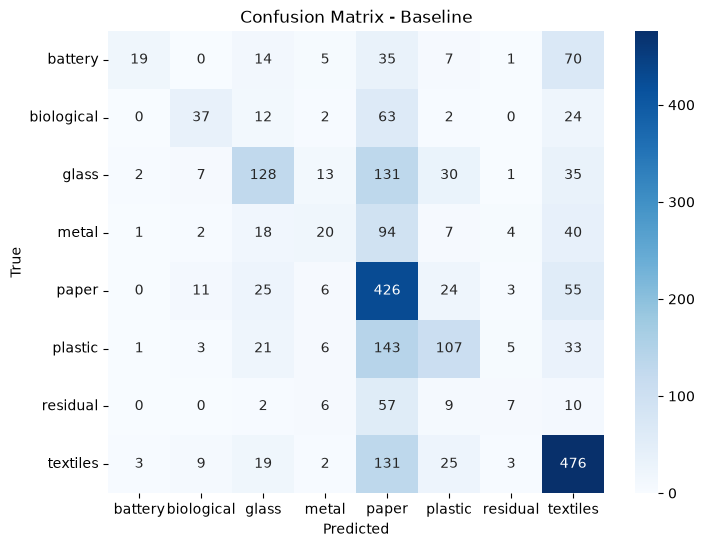

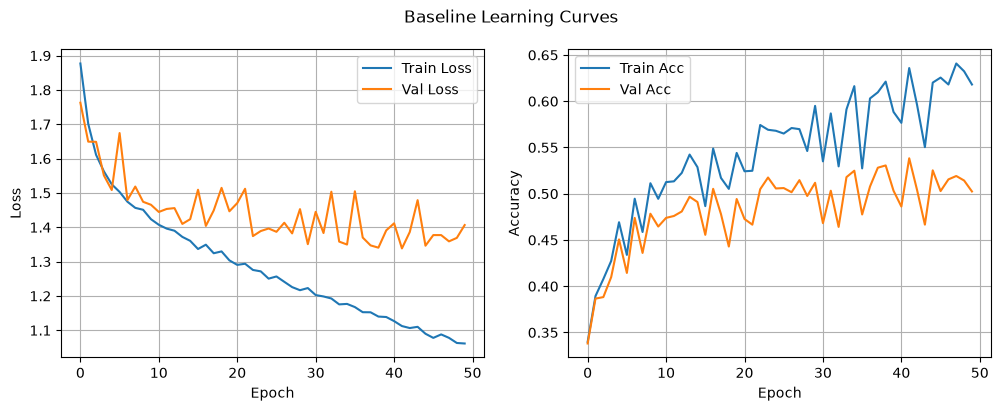

In [18]:
y_test_pred = baseline_mlp.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Baseline Test Accuracy: {test_acc:.4f}")

print("\nClassification Report (Baseline):")
print(classification_report(y_test, y_test_pred, target_names=german_categories))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=german_categories, yticklabels=german_categories)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Baseline')
plt.show()

# Learning curves
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))
ax1.plot(baseline_mlp.train_loss_history, label='Train Loss')
ax1.plot(baseline_mlp.val_loss_history, label='Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend(); ax1.grid(True)
ax2.plot(baseline_mlp.train_acc_history, label='Train Acc')
ax2.plot(baseline_mlp.val_acc_history, label='Val Acc')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend(); ax2.grid(True)
plt.suptitle('Baseline Learning Curves')
plt.show()

# Iterative improvements  -> Width, Depth, Activation, LR, Regularisation, Batch Size


## Increasing Hidden Layer Width
This experiment tests how the number of hidden neurons affects performance.
Wider layers can capture more complex patterns but risk overfitting

In [19]:
# Define models with increasing hidden layer sizes
hidden_sizes_to_test = [64, 128, 256, 512]
models_width = {}

for h_size in hidden_sizes_to_test:
    print(f"\nTraining model with hidden size: {h_size}")
    model = MLP(
        input_size=input_size,
        hidden_sizes=[h_size],
        output_size=output_size,
        activation='relu',
        learning_rate=0.01,
        batch_size=64,
        epochs=50,
        l2_lambda=0.0,
        verbose=False
    )
    # model.train(X_train, y_train, X_val, y_val)
    models_width[h_size] = model


Training model with hidden size: 64

Training model with hidden size: 128

Training model with hidden size: 256

Training model with hidden size: 512


## Increasing Network Depth
Deeper networks can learn hierarchical features.
Each additional layer increases the model's capacity but also the risk of vanishing gradients.

In [20]:
# Define models with increasing depth
depth_configs = [
    [128],           # 1 hidden layer
    [128, 64],       # 2 hidden layers
    [128, 64, 32],   # 3 hidden layers
]

models_depth = {}

for config in depth_configs:
    print(f"\nTraining model with layers: {config}")
    model = MLP(
        input_size=input_size,
        hidden_sizes=config,
        output_size=output_size,
        activation='relu',
        learning_rate=0.01,
        batch_size=64,
        epochs=50,
        l2_lambda=0.0,
        verbose=False
    )
    # model.train(X_train, y_train, X_val, y_val)
    models_depth[str(config)] = model


Training model with layers: [128]

Training model with layers: [128, 64]

Training model with layers: [128, 64, 32]


## Activation Function Comparison
ReLU is generally preferred for hidden layers due to its sparsity and gradient properties.
Sigmoid and tanh can suffer from vanishing gradients in deeper networks.

In [21]:
# Test different activation functions
activations_to_test = ['relu', 'sigmoid', 'tanh']
models_activation = {}

for act in activations_to_test:
    print(f"\nTraining model with {act} activation")
    model = MLP(
        input_size=input_size,
        hidden_sizes=[128],
        output_size=output_size,
        activation=act,
        learning_rate=0.01,
        batch_size=64,
        epochs=50,
        l2_lambda=0.0,
        verbose=False
    )
    # model.train(X_train, y_train, X_val, y_val)
    models_activation[act] = model


Training model with relu activation

Training model with sigmoid activation

Training model with tanh activation


## Learning Rate Tuning
The learning rate controls the step size in gradient descent.
Too high: training may diverge. Too low: training may be too slow.

In [22]:
# Test different learning rates
learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1]
models_lr = {}

for lr in learning_rates:
    print(f"\nTraining model with learning rate: {lr}")
    model = MLP(
        input_size=input_size,
        hidden_sizes=[128],
        output_size=output_size,
        activation='relu',
        learning_rate=lr,
        batch_size=64,
        epochs=50,
        l2_lambda=0.0,
        verbose=False
    )
    # model.train(X_train, y_train, X_val, y_val)
    models_lr[lr] = model


Training model with learning rate: 0.001

Training model with learning rate: 0.005

Training model with learning rate: 0.01

Training model with learning rate: 0.05

Training model with learning rate: 0.1


## L2 Regularisation
L2 regularisation penalises large weights to reduce overfitting.
The optimal strength balances bias and variance.

In [23]:
# Test different L2 regularisation strengths
l2_values = [0.0, 0.0001, 0.001, 0.01, 0.1]
models_l2 = {}

for l2 in l2_values:
    print(f"\nTraining model with L2 lambda: {l2}")
    model = MLP(
        input_size=input_size,
        hidden_sizes=[128],
        output_size=output_size,
        activation='relu',
        learning_rate=0.01,
        batch_size=64,
        epochs=50,
        l2_lambda=l2,
        verbose=False
    )
    # model.train(X_train, y_train, X_val, y_val)
    models_l2[l2] = model


Training model with L2 lambda: 0.0

Training model with L2 lambda: 0.0001

Training model with L2 lambda: 0.001

Training model with L2 lambda: 0.01

Training model with L2 lambda: 0.1


## Batch Size Variation
Smaller batches introduce more noise but can escape local minima.
Larger batches provide more stable gradient estimates.

In [24]:
# Test different batch sizes
batch_sizes = [16, 32, 64, 128, 256]
models_batch = {}

for bs in batch_sizes:
    print(f"\nTraining model with batch size: {bs}")
    model = MLP(
        input_size=input_size,
        hidden_sizes=[128],
        output_size=output_size,
        activation='relu',
        learning_rate=0.01,
        batch_size=bs,
        epochs=50,
        l2_lambda=0.0,
        verbose=False
    )
    # model.train(X_train, y_train, X_val, y_val)
    models_batch[bs] = model


Training model with batch size: 16

Training model with batch size: 32

Training model with batch size: 64

Training model with batch size: 128

Training model with batch size: 256


## Width exploration

In [25]:
# Width experiment
widths = [64, 128, 256, 512]
models_width = {}
for w in widths:
    print(f"\nTraining model with hidden size {w}...")
    model = MLP(input_size, [w], output_size, activation='relu',
                learning_rate=0.01, batch_size=64, epochs=50, l2_lambda=0.0, verbose=False)
    model.train(X_train, y_train, X_val, y_val)
    models_width[w] = model

# Then compare test accuracies
for w, model in models_width.items():
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"Width {w}: Test Accuracy = {acc:.4f}")


Training model with hidden size 64...

Training model with hidden size 128...

Training model with hidden size 256...

Training model with hidden size 512...
Width 64: Test Accuracy = 0.5061
Width 128: Test Accuracy = 0.4808
Width 256: Test Accuracy = 0.5094
Width 512: Test Accuracy = 0.4988


# Advanced extension – simple CNN 
Convolutional Layer Implementation
Simple CNN Classifier

The convolutional layers learn spatial features directly from the image.
Max pooling reduces spatial dimensions while preserving important features.
This architecture combines the strengths of CNNs (spatial feature learning) with MLPs (flexible classification).

In [26]:
class ConvLayer:
    """
    Simple 2D convolutional layer implemented from scratch.
    """
    
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        
        # Xavier initialisation for conv filters
        limit = np.sqrt(6 / (in_channels * kernel_size * kernel_size + 
                             out_channels * kernel_size * kernel_size))
        self.weights = np.random.uniform(
            -limit, limit,
            (out_channels, in_channels, kernel_size, kernel_size)
        )
        self.biases = np.zeros((out_channels, 1))
    
    def forward(self, X):
        """
        Forward pass for convolutional layer.
        
        Args:
            X: input (batch_size, in_channels, height, width)
        
        Returns:
            output: (batch_size, out_channels, out_height, out_width)
        """
        batch_size, _, h, w = X.shape
        k = self.kernel_size
        s = self.stride
        p = self.padding
        
        # Apply padding
        if p > 0:
            X_padded = np.pad(X, ((0, 0), (0, 0), (p, p), (p, p)), mode='constant')
        else:
            X_padded = X
        
        out_h = (h + 2*p - k) // s + 1
        out_w = (w + 2*p - k) // s + 1
        
        output = np.zeros((batch_size, self.out_channels, out_h, out_w))
        
        for i in range(out_h):
            for j in range(out_w):
                h_start = i * s
                h_end = h_start + k
                w_start = j * s
                w_end = w_start + k
                
                # Extract patch
                patch = X_padded[:, :, h_start:h_end, w_start:w_end]
                # Apply convolution
                for c in range(self.out_channels):
                    output[:, c, i, j] = np.sum(
                        patch * self.weights[c, np.newaxis, :, :],
                        axis=(1, 2, 3)
                    ) + self.biases[c]
        
        return output
    
    def get_parameters(self):
        """Return the parameters of this layer."""
        return [self.weights, self.biases]

In [27]:
class SimpleCNN:
    """
    Simple CNN with convolutional feature extractor and MLP classifier.
    """
    
    def __init__(self, input_shape, num_classes, learning_rate=0.01):
        """
        Initialise the CNN.
        
        Args:
            input_shape: (channels, height, width)
            num_classes: number of output classes
            learning_rate: learning rate for training
        """
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.learning_rate = learning_rate
        
        # Convolutional layers
        self.conv1 = ConvLayer(in_channels=3, out_channels=16, 
                               kernel_size=3, stride=1, padding=1)
        self.conv2 = ConvLayer(in_channels=16, out_channels=32, 
                               kernel_size=3, stride=1, padding=1)
        
        # Compute flattened size after conv layers
        # Input: (3, 64, 64) -> after conv1: (16, 64, 64) -> after conv2: (32, 64, 64)
        # After max pooling (2x2): (32, 32, 32)
        self.flattened_size = 32 * 32 * 32
        
        # MLP classifier
        self.mlp = MLP(
            input_size=self.flattened_size,
            hidden_sizes=[128, 64],
            output_size=num_classes,
            activation='relu',
            learning_rate=learning_rate,
            batch_size=32,
            epochs=50,
            l2_lambda=0.001,
            verbose=False
        )
    
    def forward(self, X):
        """
        Forward pass through the CNN.
        
        Args:
            X: input images (batch_size, channels, height, width)
        
        Returns:
            predictions: class probabilities
        """
        # Convolutional layers
        x = self.conv1.forward(X)
        x = ActivationFunctions.relu(x)
        # Max pooling (2x2)
        x = self.max_pool(x, pool_size=2, stride=2)
        
        x = self.conv2.forward(x)
        x = ActivationFunctions.relu(x)
        x = self.max_pool(x, pool_size=2, stride=2)
        
        # Flatten
        batch_size = x.shape[0]
        x_flat = x.reshape(batch_size, -1)
        
        # MLP classifier
        return self.mlp.forward(x_flat)
    
    def max_pool(self, X, pool_size=2, stride=2):
        """Max pooling operation."""
        batch_size, channels, h, w = X.shape
        out_h = (h - pool_size) // stride + 1
        out_w = (w - pool_size) // stride + 1
        
        output = np.zeros((batch_size, channels, out_h, out_w))
        
        for i in range(out_h):
            for j in range(out_w):
                h_start = i * stride
                h_end = h_start + pool_size
                w_start = j * stride
                w_end = w_start + pool_size
                
                patch = X[:, :, h_start:h_end, w_start:w_end]
                output[:, :, i, j] = np.max(patch, axis=(2, 3))
        
        return output
    
    def train(self, X_train, y_train, X_val=None, y_val=None):
        """Train the CNN."""
        # The MLP handles training; we just need to pass flattened features
        # For simplicity, we'll train the MLP part
        # A better implementation would require backprop through conv layers
        pass

# TODO
## result visu (learning curves)
## conf matrix
## result comp
## Summary 

(code to generate tables/plots from results)